## Preperation

In [1]:
import os
from tqdm import tqdm
import torch
import random
import numpy as np
import torch.nn as nn
from Model import EEGModel, AverageEnsemble, LinearEnsemble
from Data import EEGDataLoader
from Evaluation import visualizer
from Evaluation import ExperimentDataSaver

In [2]:
DATA_PATH = '.\\RawDataset\\'
CACHE_PATH = '.\\Dataset\\'
MODEL_PATH = '.\\Models\\'
data_saver = ExperimentDataSaver(root_path='.\\Results\\')

CRITERION = nn.CrossEntropyLoss()
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_ARCHITECTURES = ['DeepConvNet', 'ShallowFBCSPNet', 'CTNet', 'Deep4Net']

SUBJECT_COUNT = 15
LEARNING_RATE = 0.005
P_LEARNING_RATE = 0.01
BATCH_SIZE = 8
P_BATCH_SIZE = 16
LOG_INTERVAL = 5
MAX_EPOCH = 50
PATIENCE = 7
K_FOLDS = 5
RANDOM_SEED = 42
SPLIT = (0.7, 0.1, 0.2)

In [3]:
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

## DataLoading

Target Classes: ['Elbow Flexion', 'Elbow Extension', 'Supination', 'Pronation', 'Hand Open', 'Hand Close', 'Rest']


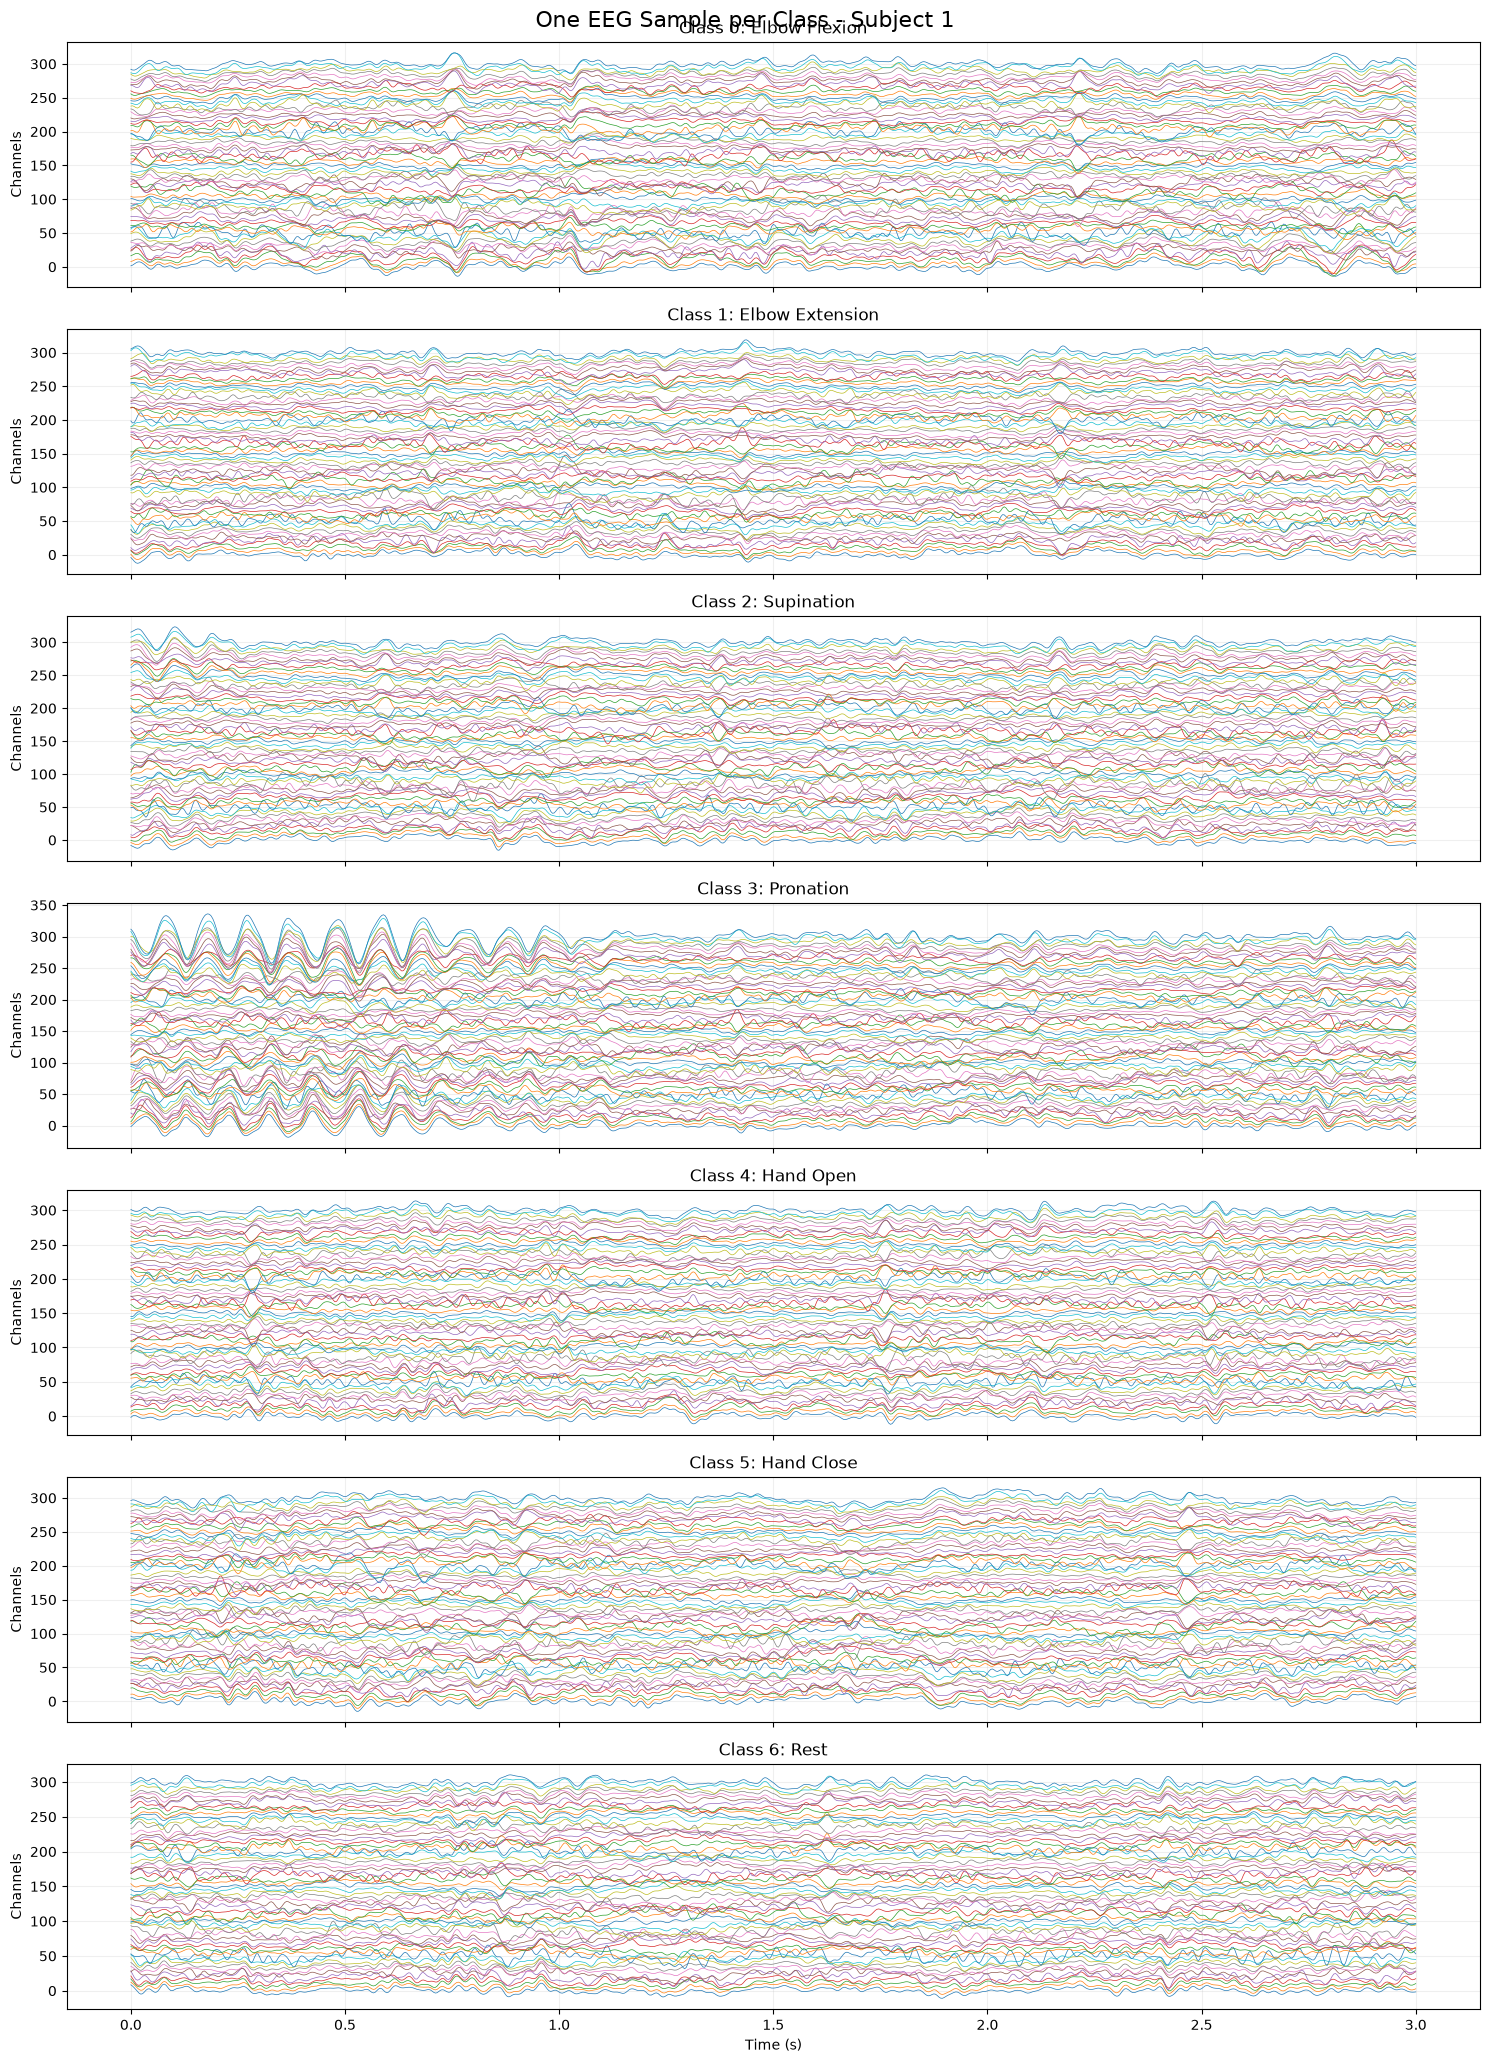

In [4]:
data_loader_factory = EEGDataLoader(
    data_path=DATA_PATH, 
    cache_path=CACHE_PATH, 
    batch_size=BATCH_SIZE,
    split_ratios=SPLIT
)

classes = data_loader_factory.get_class_names()
print(f"Target Classes: {classes}")
visualizer.visualize_one_sample_per_label(
    data_loader_factory,
    subject=1
)

## Models and Architectures 

In [5]:
for architecture in MODEL_ARCHITECTURES:
    print('#' * 25, architecture, '#' * 25)
    model = EEGModel(
        criterion=CRITERION,
        learning_rate=LEARNING_RATE,
        architecture_key=architecture,
        random_seed=RANDOM_SEED,
        device=DEVICE
    )
    model.model_summary()
    print('#' * 65)

######################### DeepConvNet #########################
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 25, 61, 760]             250
            Conv2d-2           [-1, 25, 1, 760]          38,125
       BatchNorm2d-3           [-1, 25, 1, 760]              50
               ELU-4           [-1, 25, 1, 760]               0
         MaxPool2d-5           [-1, 25, 1, 253]               0
           Dropout-6           [-1, 25, 1, 253]               0
            Conv2d-7           [-1, 50, 1, 244]          12,500
       BatchNorm2d-8           [-1, 50, 1, 244]             100
               ELU-9           [-1, 50, 1, 244]               0
        MaxPool2d-10            [-1, 50, 1, 81]               0
          Dropout-11            [-1, 50, 1, 81]               0
           Conv2d-12           [-1, 100, 1, 72]          50,000
      BatchNorm2d-13           [-1, 100

## Base-Line

### Solid Training 

#################### Selected Architecture: DeepConvNet ####################
Loading Subject 1 from cache...
Normalizing data based on training set statistics...
Subject #1:	Train Acc: 90.09	Test Acc: 45.16	Validation Acc: 45.65
Loading Subject 2 from cache...
Normalizing data based on training set statistics...
Subject #2:	Train Acc: 94.12	Test Acc: 37.63	Validation Acc: 52.17
Loading Subject 3 from cache...
Normalizing data based on training set statistics...
Subject #3:	Train Acc: 97.52	Test Acc: 96.77	Validation Acc: 91.30
Loading Subject 4 from cache...
Normalizing data based on training set statistics...
Subject #4:	Train Acc: 97.83	Test Acc: 87.10	Validation Acc: 93.48
Loading Subject 5 from cache...
Normalizing data based on training set statistics...
Subject #5:	Train Acc: 77.40	Test Acc: 39.78	Validation Acc: 34.78
Loading Subject 6 from cache...
Normalizing data based on training set statistics...
Subject #6:	Train Acc: 95.36	Test Acc: 45.16	Validation Acc: 47.83
Loading Sub

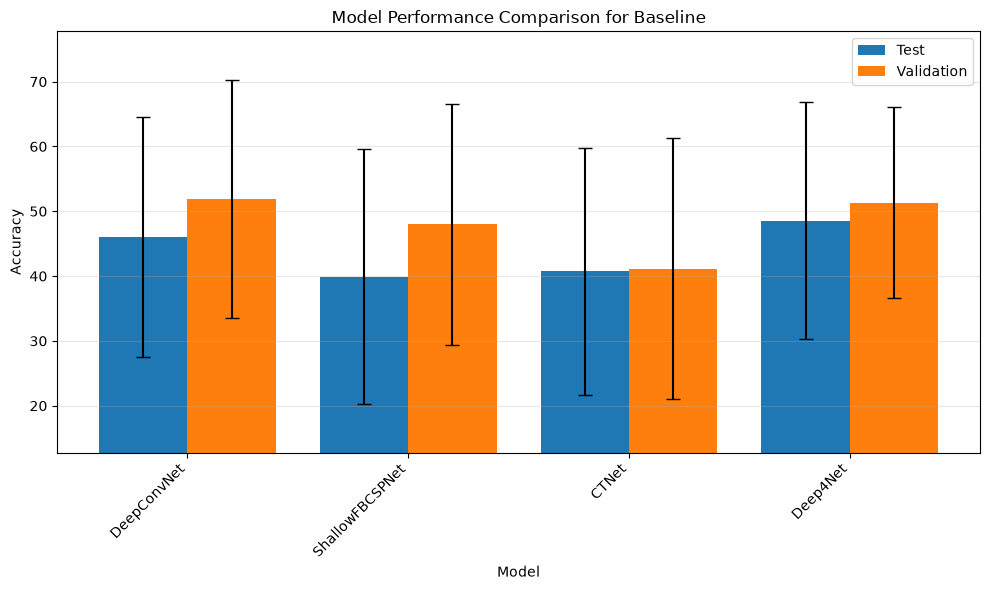

In [ ]:
test_mean, test_var, val_mean, val_var = [], [], [], []
for architecture in MODEL_ARCHITECTURES:
    print('#' * 20, 'Selected Architecture:', architecture, '#' * 20)
    test_accs, val_accs = [], []
    for subject_id in range(1, 1 + SUBJECT_COUNT):
        train_loader, val_loader, test_loader = data_loader_factory.get_dataloaders(subject=subject_id, random_seed=RANDOM_SEED)
        model_path = str(MODEL_PATH + f'Subject {subject_id}\\{architecture}_{LEARNING_RATE}.pth')
        model = EEGModel(
            criterion=CRITERION,
            learning_rate=LEARNING_RATE,
            architecture_key=architecture,
            random_seed=RANDOM_SEED,
            device=DEVICE
        )
        model.fit(
            train_loader=train_loader,
            val_loader=val_loader,
            max_epochs=MAX_EPOCH,
            patience=PATIENCE,
            save_path=model_path,
            verbose=False
        )

        test_acc = model.evaluate_accuracy(test_loader)
        val_acc = model.evaluate_accuracy(val_loader)
        train_acc = model.evaluate_accuracy(train_loader)
        test_accs.append(test_acc)
        val_accs.append(val_acc)
        print(f'Subject #{subject_id}:\tTrain Acc: {train_acc:.2f}\tTest Acc: {test_acc:.2f}\tValidation Acc: {val_acc:.2f}')

        data_saver.set_data(architecture, 'Train', 'avg', subject_id, train_acc)
        data_saver.set_data(architecture, 'Train', 'std', subject_id, None)
        data_saver.set_data(architecture, 'Validation', 'avg', subject_id, val_acc)
        data_saver.set_data(architecture, 'Validation', 'std', subject_id, None)
        data_saver.set_data(architecture, 'Test', 'avg', subject_id, test_acc)
        data_saver.set_data(architecture, 'Test', 'std', subject_id, None)

    test_mean.append(np.mean(test_accs))
    test_var.append(np.var(test_accs))
    val_mean.append(np.mean(val_accs))
    val_var.append(np.var(val_accs))
    print('Results for Model Accuracy')
    print(f'Validation: ~N({test_mean[-1]:.3f}, {test_var[-1]:.3f}), Test: ~N({val_mean[-1]:.3f}, {val_var[-1]:.3f})\n\n')

data_saver.save_excel("Results.xlsx", "Baseline")
visualizer.plot_model_performance(
    MODEL_ARCHITECTURES,
    means=[test_mean, val_mean],
    vars=[test_var, val_var],
    legend=['Test', 'Validation'],
    plot_name="Model Performance Comparison for Baseline"
)

### K-Fold Training

Selected Architecture: DeepConvNet

============= Evaluating Subject #1 =============
Loading Subject 1 from cache...

==================== Fold 1/5 ====================
Normalizing using training-set statistics...

==================== Fold 2/5 ====================
Normalizing using training-set statistics...

==================== Fold 3/5 ====================
Normalizing using training-set statistics...

==================== Fold 4/5 ====================
Normalizing using training-set statistics...

==================== Fold 5/5 ====================
Normalizing using training-set statistics...
Model loaded successfully from .\Models\Subject 1\Fold_1_DeepConvNet_0.005.pth
  Fold 1:	Train Acc: 75.61	Val Acc: 52.69
Model loaded successfully from .\Models\Subject 1\Fold_2_DeepConvNet_0.005.pth
  Fold 2:	Train Acc: 80.49	Val Acc: 48.39
Model loaded successfully from .\Models\Subject 1\Fold_3_DeepConvNet_0.005.pth
  Fold 3:	Train Acc: 69.73	Val Acc: 46.74
Model loaded successfully from .\M

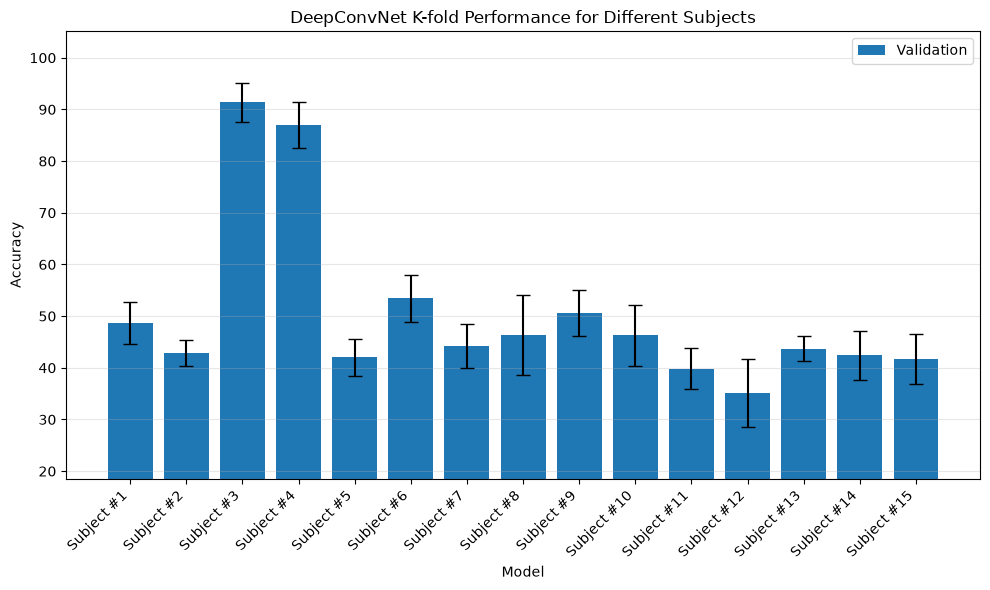

Selected Architecture: ShallowFBCSPNet

============= Evaluating Subject #1 =============
Loading Subject 1 from cache...

==================== Fold 1/5 ====================
Normalizing using training-set statistics...

==================== Fold 2/5 ====================
Normalizing using training-set statistics...

==================== Fold 3/5 ====================
Normalizing using training-set statistics...

==================== Fold 4/5 ====================
Normalizing using training-set statistics...

==================== Fold 5/5 ====================
Normalizing using training-set statistics...
Model loaded successfully from .\Models\Subject 1\Fold_1_ShallowFBCSPNet_0.005.pth
  Fold 1:	Train Acc: 65.31	Val Acc: 30.11
Model loaded successfully from .\Models\Subject 1\Fold_2_ShallowFBCSPNet_0.005.pth
  Fold 2:	Train Acc: 60.98	Val Acc: 30.11
Model loaded successfully from .\Models\Subject 1\Fold_3_ShallowFBCSPNet_0.005.pth
  Fold 3:	Train Acc: 92.70	Val Acc: 43.48
Model loaded succe

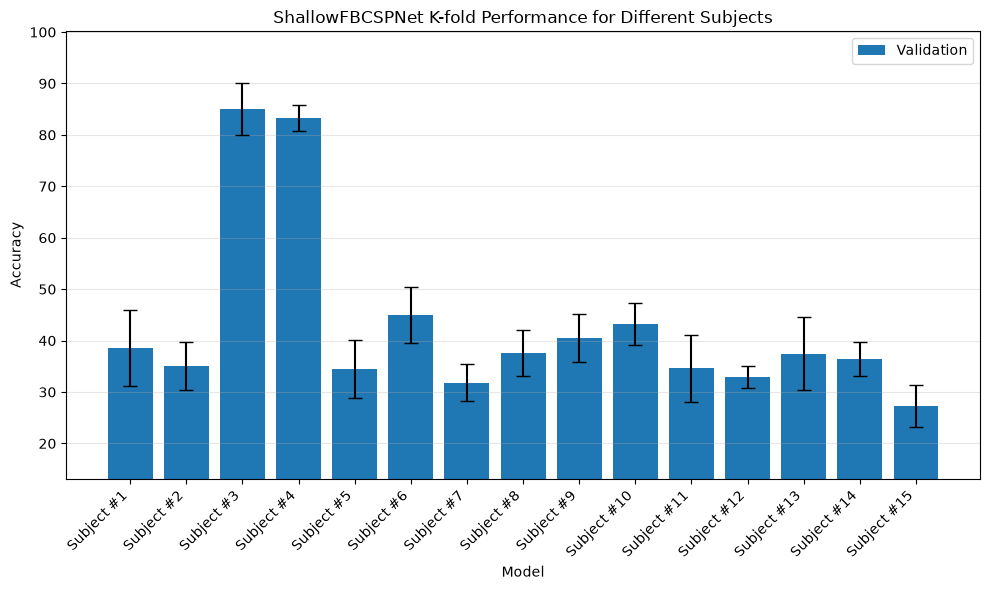

Selected Architecture: CTNet

============= Evaluating Subject #1 =============
Loading Subject 1 from cache...

==================== Fold 1/5 ====================
Normalizing using training-set statistics...

==================== Fold 2/5 ====================
Normalizing using training-set statistics...

==================== Fold 3/5 ====================
Normalizing using training-set statistics...

==================== Fold 4/5 ====================
Normalizing using training-set statistics...

==================== Fold 5/5 ====================
Normalizing using training-set statistics...
Model loaded successfully from .\Models\Subject 1\Fold_1_CTNet_0.005.pth
  Fold 1:	Train Acc: 57.99	Val Acc: 34.41
Model loaded successfully from .\Models\Subject 1\Fold_2_CTNet_0.005.pth
  Fold 2:	Train Acc: 84.55	Val Acc: 39.78
Model loaded successfully from .\Models\Subject 1\Fold_3_CTNet_0.005.pth
  Fold 3:	Train Acc: 62.70	Val Acc: 19.57
Model loaded successfully from .\Models\Subject 1\Fold_4_C

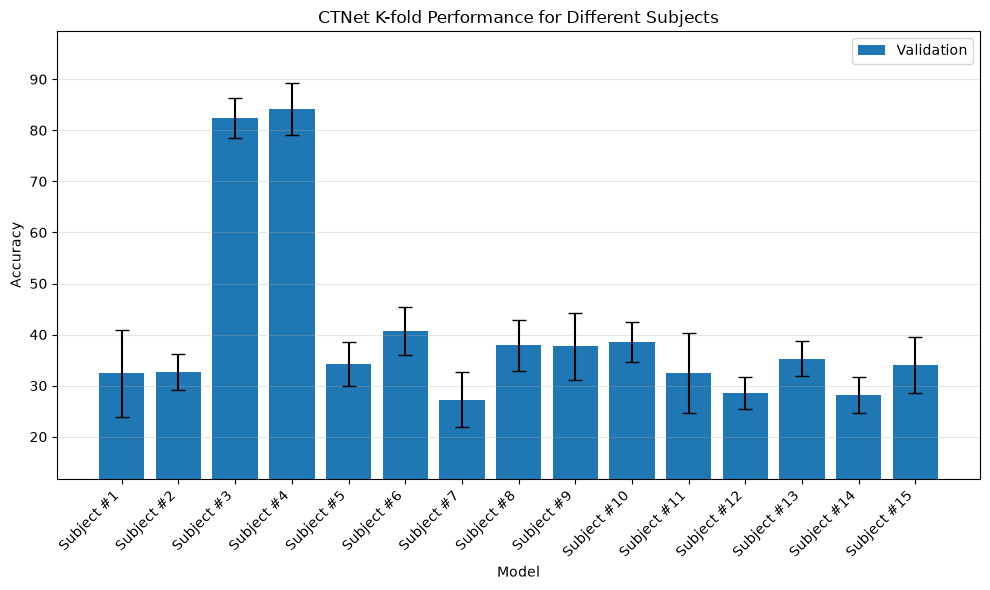

Selected Architecture: Deep4Net

============= Evaluating Subject #1 =============
Loading Subject 1 from cache...

==================== Fold 1/5 ====================
Normalizing using training-set statistics...

==================== Fold 2/5 ====================
Normalizing using training-set statistics...

==================== Fold 3/5 ====================
Normalizing using training-set statistics...

==================== Fold 4/5 ====================
Normalizing using training-set statistics...

==================== Fold 5/5 ====================
Normalizing using training-set statistics...
Model loaded successfully from .\Models\Subject 1\Fold_1_Deep4Net_0.005.pth
  Fold 1:	Train Acc: 94.31	Val Acc: 60.22
Model loaded successfully from .\Models\Subject 1\Fold_2_Deep4Net_0.005.pth
  Fold 2:	Train Acc: 83.47	Val Acc: 52.69
Model loaded successfully from .\Models\Subject 1\Fold_3_Deep4Net_0.005.pth
  Fold 3:	Train Acc: 83.24	Val Acc: 55.43
Model loaded successfully from .\Models\Subjec

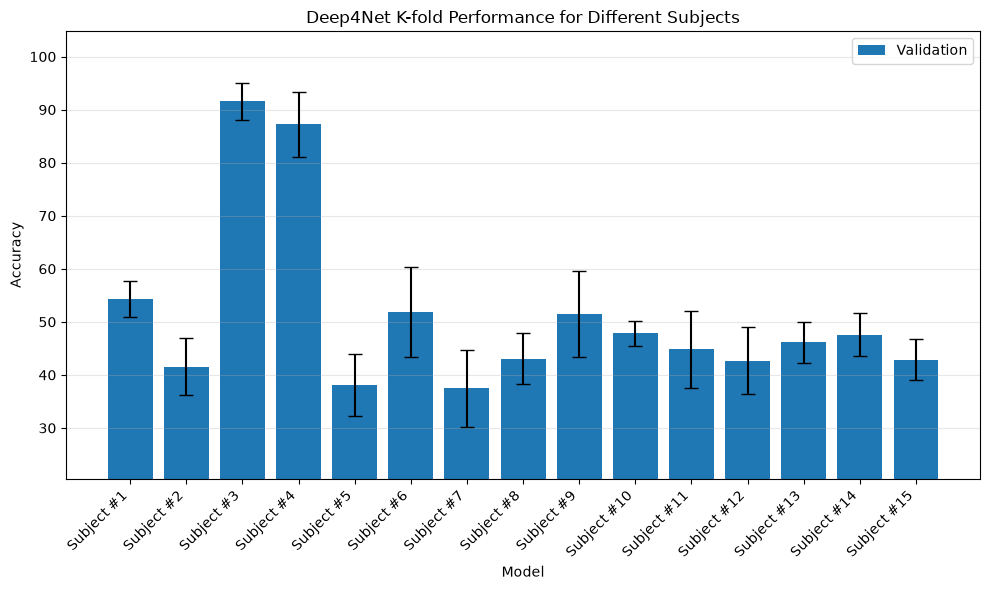

Data saved successfully to .\Results\Results.xlsx (Sheet: Baseline K-fold)


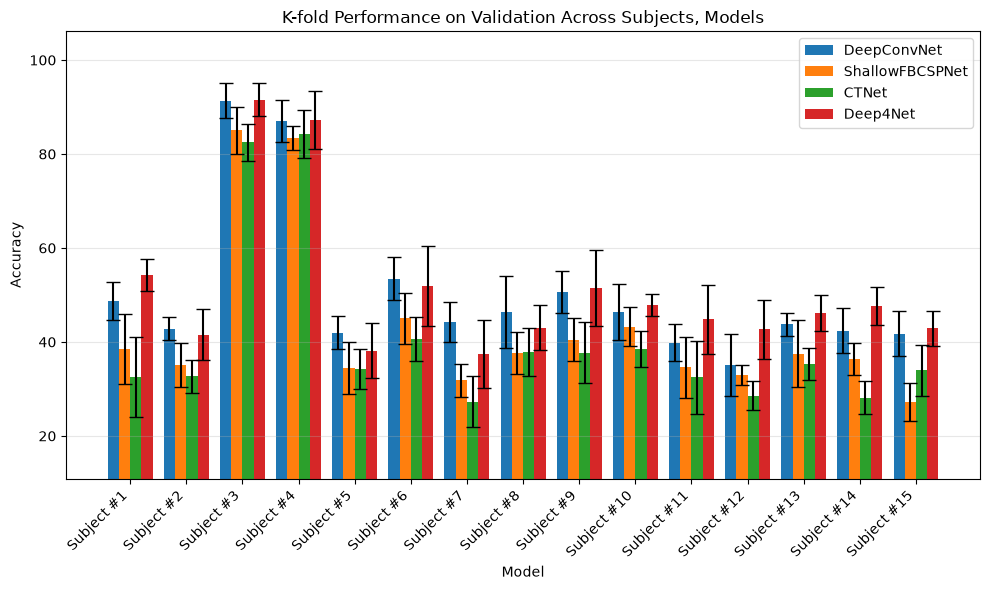

In [ ]:
val_means, val_vars = [], []
for architecture in MODEL_ARCHITECTURES:
    val_mean, val_var = [], []
    print(f'Selected Architecture: {architecture}')

    for subject_id in range(1, 1 + SUBJECT_COUNT):
        print(f'\n============= Evaluating Subject #{subject_id} =============')
        fold_loaders = data_loader_factory.get_k_fold_dataloaders(subject=subject_id, k=K_FOLDS, random_seed=RANDOM_SEED)
        val_accs, train_accs = [], []

        for fold_idx, (train_loader, val_loader) in enumerate(fold_loaders):
            model_path = str(MODEL_PATH + f'Subject {subject_id}\\Fold_{fold_idx+1}_{architecture}_{LEARNING_RATE}.pth')
            model = EEGModel(
                criterion=CRITERION,
                learning_rate=LEARNING_RATE,
                architecture_key=architecture,
                random_seed=RANDOM_SEED,
                device=DEVICE
            )
            # model.fit(
            #     train_loader=train_loader,
            #     val_loader=val_loader,
            #     max_epochs=MAX_EPOCH,
            #     patience=PATIENCE,
            #     save_path=model_path,
            #     verbose=False
            # )
            model.load_model(model_path)

            final_val_acc = model.evaluate_accuracy(val_loader)
            final_train_acc = model.evaluate_accuracy(train_loader)
            val_accs.append(final_val_acc)
            train_accs.append(final_train_acc)
            print(f'  Fold {fold_idx + 1}:\tTrain Acc: {final_train_acc:.2f}\tVal Acc: {final_val_acc:.2f}')
        
        val_mean.append(np.mean(val_accs))
        val_var.append(np.var(val_accs))
        print(f'\nModel Accuracy (Averaged over Folds) Validation: ~N({val_mean[-1]:.3f}, {val_var[-1]:.3f})\n')
        t_avg, t_std = np.mean(train_accs), np.std(train_accs)
        v_avg, v_std = np.mean(val_accs), np.std(val_accs)
        
        data_saver.set_data(architecture, 'Train', 'avg', subject_id, t_avg)
        data_saver.set_data(architecture, 'Train', 'std', subject_id, t_std)
        data_saver.set_data(architecture, 'Validation', 'avg', subject_id, v_avg)
        data_saver.set_data(architecture, 'Validation', 'std', subject_id, v_std)
        data_saver.set_data(architecture, 'Test', 'avg', subject_id, None)
        data_saver.set_data(architecture, 'Test', 'std', subject_id, None)

    visualizer.plot_model_performance(
        [f'Subject #{i + 1}' for i in range(SUBJECT_COUNT)],
        means=[val_mean],
        vars=[val_var],
        legend=['Validation'],
        plot_name=f"{architecture} K-fold Performance for Different Subjects"
    )
    val_means.append(val_mean)
    val_vars.append(val_var)

data_saver.save_excel("Results.xlsx", 'Baseline K-fold')
visualizer.plot_model_performance(
    [f'Subject #{i + 1}' for i in range(SUBJECT_COUNT)],
    means=val_means,
    vars=val_vars,
    legend=MODEL_ARCHITECTURES,
    plot_name=f"K-fold Performance on Validation Across Subjects, Models"
)

## Pretraining

### Core Training


-------- Setting up training for ALL Subjects --------
Loading Subject 1 from cache...
Normalizing data based on training set statistics...
Loading Subject 2 from cache...
Normalizing data based on training set statistics...
Loading Subject 3 from cache...
Normalizing data based on training set statistics...
Loading Subject 4 from cache...
Normalizing data based on training set statistics...
Loading Subject 5 from cache...
Normalizing data based on training set statistics...
Loading Subject 6 from cache...
Normalizing data based on training set statistics...
Loading Subject 7 from cache...
Normalizing data based on training set statistics...
Loading Subject 8 from cache...
Normalizing data based on training set statistics...
Loading Subject 9 from cache...
Normalizing data based on training set statistics...
Loading Subject 10 from cache...
Normalizing data based on training set statistics...
Loading Subject 11 from cache...
Normalizing data based on training set statistics...
Loading

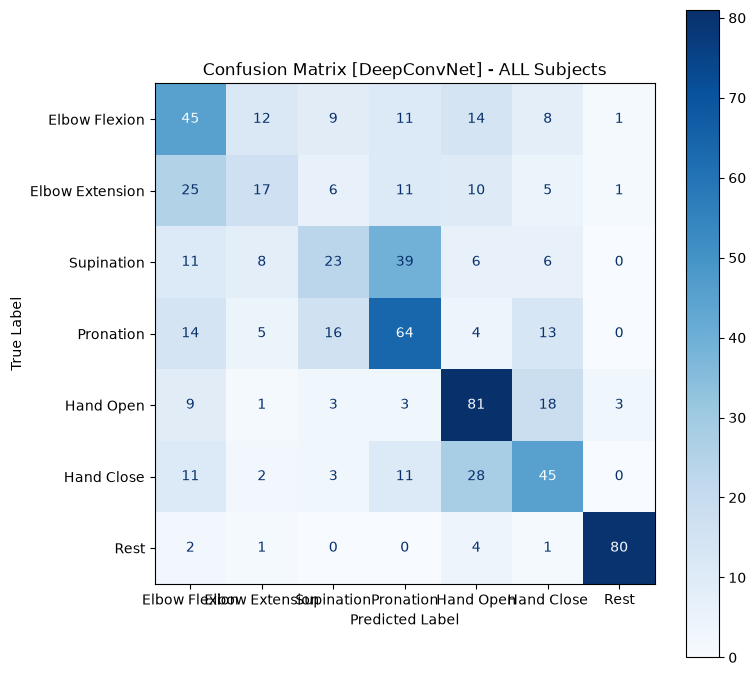


Selected Architecture: ShallowFBCSPNet
Model loaded successfully from .\Models\Pretrained\ShallowFBCSPNet_0.01_RemovedSubject#0.pth

Model Final Accuracy:
	Train: 63.405572755417964
	Validation: 47.391304347826086


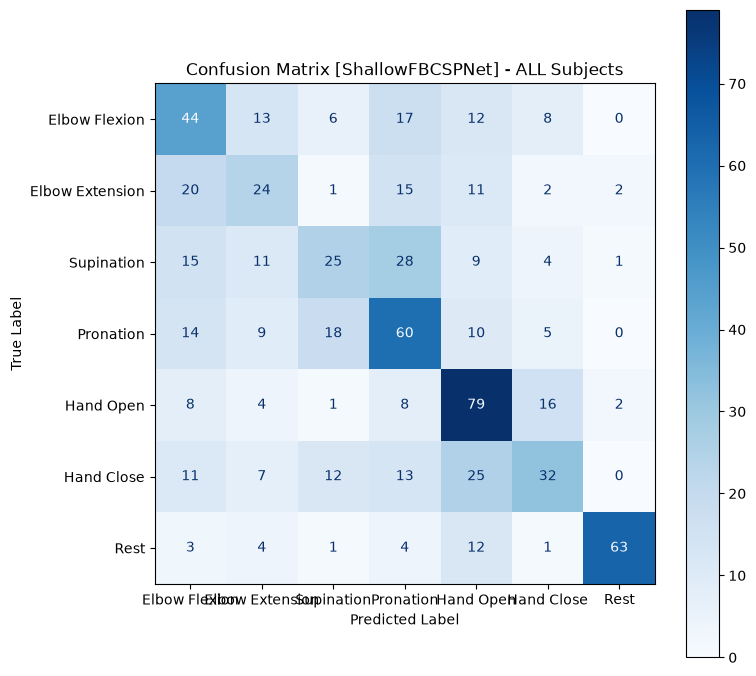


Selected Architecture: CTNet
Model loaded successfully from .\Models\Pretrained\CTNet_0.01_RemovedSubject#0.pth

Model Final Accuracy:
	Train: 64.78844169246646
	Validation: 47.971014492753625


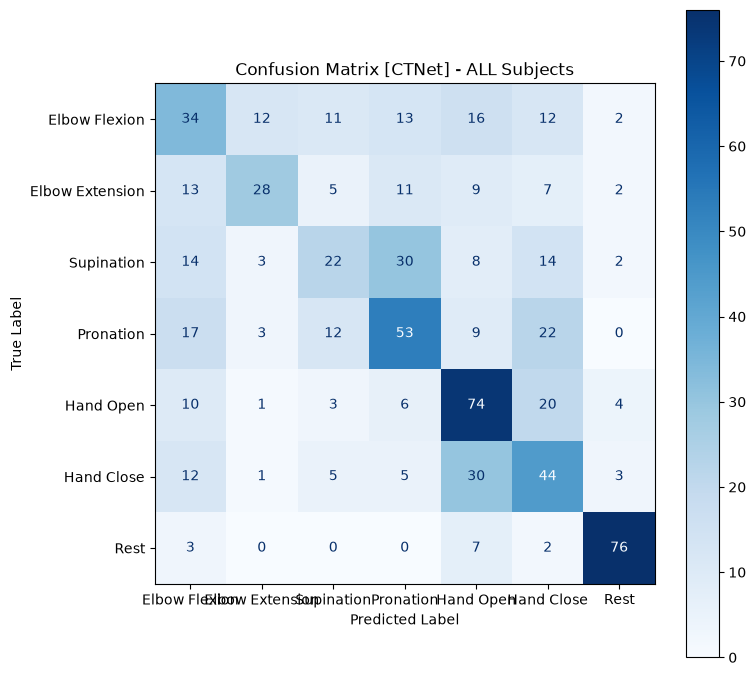


Selected Architecture: Deep4Net
Model loaded successfully from .\Models\Pretrained\Deep4Net_0.01_RemovedSubject#0.pth

Model Final Accuracy:
	Train: 54.96388028895769
	Validation: 48.40579710144928


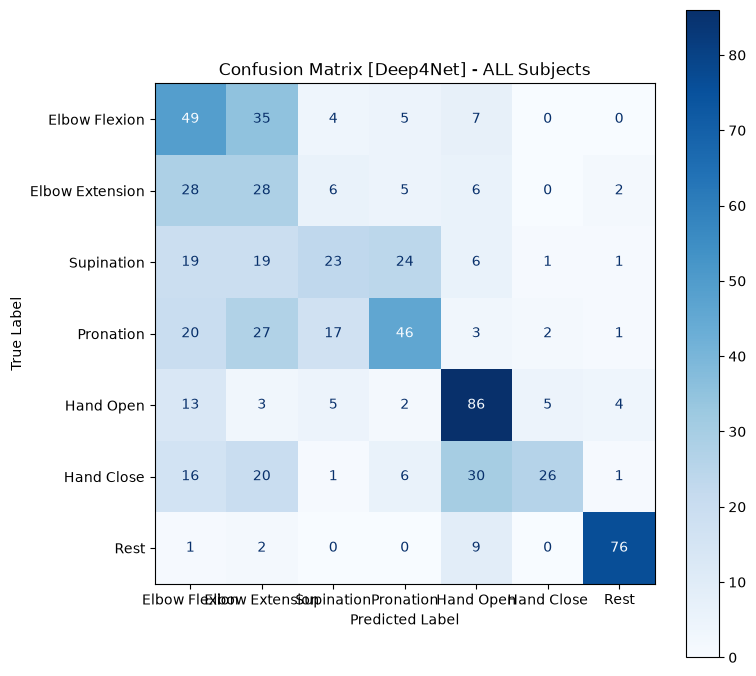

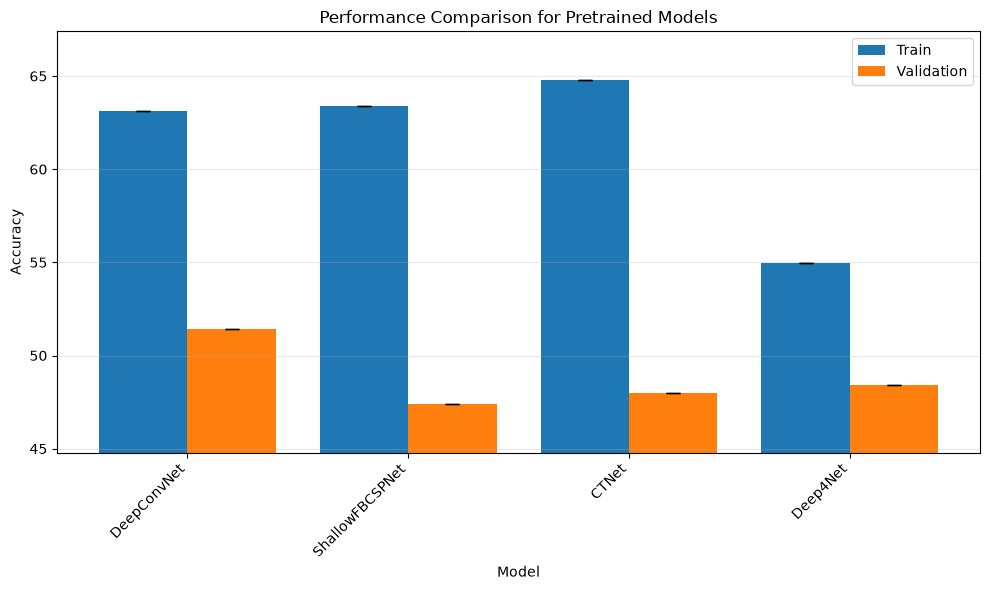


-------- Setting up training for ALL Subjects Except 1--------
Loading Subject 2 from cache...
Normalizing data based on training set statistics...
Loading Subject 3 from cache...
Normalizing data based on training set statistics...
Loading Subject 4 from cache...
Normalizing data based on training set statistics...
Loading Subject 5 from cache...
Normalizing data based on training set statistics...
Loading Subject 6 from cache...
Normalizing data based on training set statistics...
Loading Subject 7 from cache...
Normalizing data based on training set statistics...
Loading Subject 8 from cache...
Normalizing data based on training set statistics...
Loading Subject 9 from cache...
Normalizing data based on training set statistics...
Loading Subject 10 from cache...
Normalizing data based on training set statistics...
Loading Subject 11 from cache...
Normalizing data based on training set statistics...
Loading Subject 12 from cache...
Normalizing data based on training set statistics..

In [ ]:
for subject_removed in range(SUBJECT_COUNT + 1):
    print(f"\n-------- Setting up training for ALL Subjects {'' if subject_removed == 0 else f'Except {subject_removed}'}--------")
    subjects=[i for i in range(1, SUBJECT_COUNT + 1)]
    if subject_removed != 0:
        subjects.remove(subject_removed)
    full_train_loader = data_loader_factory.combined_dataloaders(subjects=subjects, batch_size=P_BATCH_SIZE, random_seed=RANDOM_SEED)
    full_val_loader = data_loader_factory.combined_dataloaders(subjects=subjects, batch_size=P_BATCH_SIZE, random_seed=RANDOM_SEED, train=False)
    train_acc, val_acc = [], []
    for architecture in MODEL_ARCHITECTURES:
        print('\nSelected Architecture:', architecture)
        model_path = str(MODEL_PATH + f'Pretrained\\{architecture}_{P_LEARNING_RATE}_RemovedSubject#{subject_removed}.pth')
        model = EEGModel(
            criterion=CRITERION,
            learning_rate=P_LEARNING_RATE,
            architecture_key=architecture,
            random_seed=RANDOM_SEED,
            device=DEVICE
        )
        # model.fit(
        #     train_loader=full_train_loader,
        #     val_loader=full_val_loader,
        #     max_epochs=MAX_EPOCH,
        #     patience=PATIENCE,
        #     save_path=model_path,
        #     verbose=(subject_removed == 0)
        # )
        model.load_model(model_path)

        train_acc.append(model.evaluate_accuracy(full_train_loader))
        val_acc.append(model.evaluate_accuracy(full_val_loader))
        print('\nModel Final Accuracy:')
        print('\tTrain:', train_acc[-1])
        print('\tValidation:', val_acc[-1])

        data_saver.set_data(architecture, 'Train', 'avg', subject_removed, train_acc[-1])
        data_saver.set_data(architecture, 'Validation', 'avg', subject_removed, val_acc[-1])
        if subject_removed == 0:
            visualizer.plot_confusion_matrix(
                model=model,
                data_loader=full_val_loader,
                class_names=classes,
                title=f'Confusion Matrix [{architecture}] - ALL Subjects'
            )
    if subject_removed == 0:
        visualizer.plot_model_performance(
            MODEL_ARCHITECTURES,
            means=[train_acc, val_acc],
            vars=[np.zeros(len(train_acc)), np.zeros(len(val_acc))],
            legend=['Train', 'Validation'],
            plot_name="Performance Comparison for Pretrained Models"
        )
data_saver.save_excel("Results.xlsx", 'Pretrained')

### Fine-tunning on fully trained

#################### Selected Architecture: DeepConvNet ####################
Loading Subject 1 from cache...
Normalizing data based on training set statistics...
Model loaded successfully from .\Models\Subject 1\Finetuned_DeepConvNet_0.005.pth
Subject #1:	Test Acc: 56.9892	Validation Acc: 58.6957
Loading Subject 2 from cache...
Normalizing data based on training set statistics...
Model loaded successfully from .\Models\Subject 2\Finetuned_DeepConvNet_0.005.pth
Subject #2:	Test Acc: 53.7634	Validation Acc: 43.4783
Loading Subject 3 from cache...
Normalizing data based on training set statistics...
Model loaded successfully from .\Models\Subject 3\Finetuned_DeepConvNet_0.005.pth
Subject #3:	Test Acc: 93.5484	Validation Acc: 91.3043
Loading Subject 4 from cache...
Normalizing data based on training set statistics...
Model loaded successfully from .\Models\Subject 4\Finetuned_DeepConvNet_0.005.pth
Subject #4:	Test Acc: 92.4731	Validation Acc: 97.8261
Loading Subject 5 from cache...
Normali

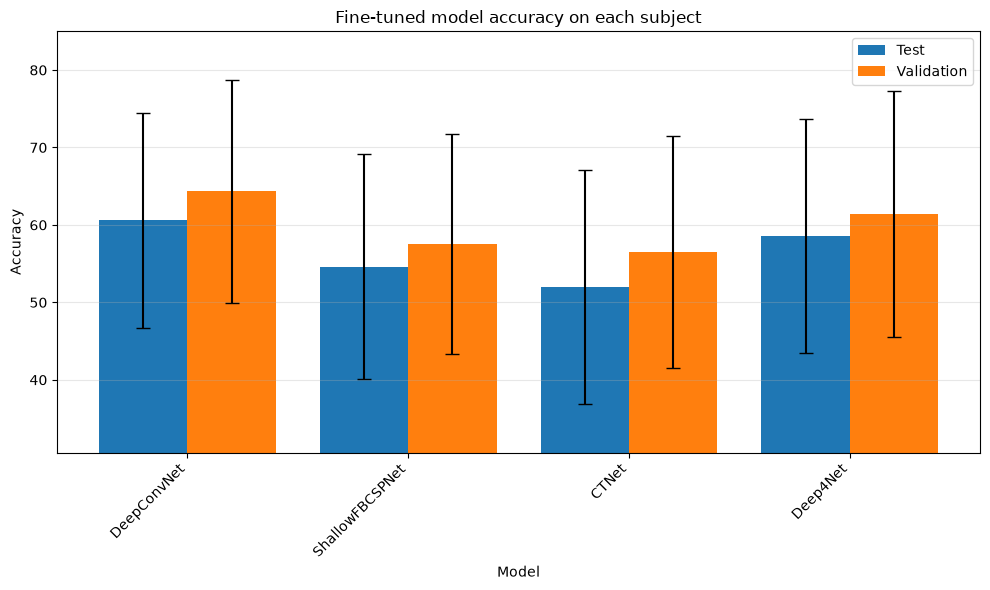

Data saved successfully to .\Results\Results.xlsx (Sheet: Fine-tune on Full)


In [9]:
test_mean, test_var, val_mean, val_var = [], [], [], []
for architecture in MODEL_ARCHITECTURES:
    print('#' * 20, 'Selected Architecture:', architecture, '#' * 20)
    train_accs, test_accs, val_accs = [], [], []
    for subject_id in range(1, 1 + SUBJECT_COUNT):
        train_loader, val_loader, test_loader = data_loader_factory.get_dataloaders(subject=subject_id, random_seed=RANDOM_SEED)
        pretrained_model_path = str(MODEL_PATH + f'Pretrained\\{architecture}_{P_LEARNING_RATE}_RemovedSubject#0.pth')
        model_path = str(MODEL_PATH + f'Subject {subject_id}\\Finetuned_{architecture}_{LEARNING_RATE}.pth')
        model = EEGModel(
            criterion=CRITERION,
            learning_rate=LEARNING_RATE,
            architecture_key=architecture,
            random_seed=RANDOM_SEED,
            device=DEVICE
        )
        # model.load_model(pretrained_model_path, verbose=False)
        # model.fit(
        #     train_loader=train_loader,
        #     val_loader=val_loader,
        #     max_epochs=MAX_EPOCH,
        #     patience=PATIENCE,
        #     save_path=model_path,
        #     verbose=True
        # )
        
        model.load_model(model_path)
        train_acc = model.evaluate_accuracy(train_loader)
        test_acc = model.evaluate_accuracy(test_loader)
        val_acc = model.evaluate_accuracy(val_loader)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        val_accs.append(val_acc)
        data_saver.set_data(architecture, 'Train', 'avg', subject_id, train_acc)
        data_saver.set_data(architecture, 'Test', 'avg', subject_id, test_acc)
        data_saver.set_data(architecture, 'Validation', 'avg', subject_id, val_acc)
        print(f'Subject #{subject_id}:\tTest Acc: {test_acc:.4f}\tValidation Acc: {val_acc:.4f}')
    test_mean.append(np.mean(test_accs))
    test_var.append(np.var(test_accs))
    val_mean.append(np.mean(val_accs))
    val_var.append(np.var(val_accs))
    print('Results for Model Accuracy')
    print(f'Validation: ~N({test_mean[-1]:.3f}, {test_var[-1]:.3f}), Test: ~N({val_mean[-1]:.3f}, {val_var[-1]:.3f})\n')

visualizer.plot_model_performance(
    MODEL_ARCHITECTURES,
    means=[test_mean, val_mean],
    vars=[test_var, val_var],
    legend=['Test', 'Validation'],
    plot_name="Fine-tuned model accuracy on each subject"
)
data_saver.save_excel("Results.xlsx", 'Fine-tune on Full')

### Fine-tunning subject evaluation (14 vs 1)


-------- Setting up Fine-tunning for on Subject #1--------
Loading Subject 1 from cache...
Normalizing data based on training set statistics...

Selected Architecture: DeepConvNet
Model loaded successfully from .\Models\Subject 1\Finetuned_14vs1_DeepConvNet_0.005.pth

Model Final Accuracy:
	Train: 68.42105263157895
	Validation: 45.65217391304348

Selected Architecture: ShallowFBCSPNet
Model loaded successfully from .\Models\Subject 1\Finetuned_14vs1_ShallowFBCSPNet_0.005.pth

Model Final Accuracy:
	Train: 74.30340557275542
	Validation: 52.17391304347826

Selected Architecture: CTNet
Model loaded successfully from .\Models\Subject 1\Finetuned_14vs1_CTNet_0.005.pth

Model Final Accuracy:
	Train: 58.51393188854489
	Validation: 32.608695652173914

Selected Architecture: Deep4Net
Model loaded successfully from .\Models\Subject 1\Finetuned_14vs1_Deep4Net_0.005.pth

Model Final Accuracy:
	Train: 68.73065015479877
	Validation: 47.82608695652174


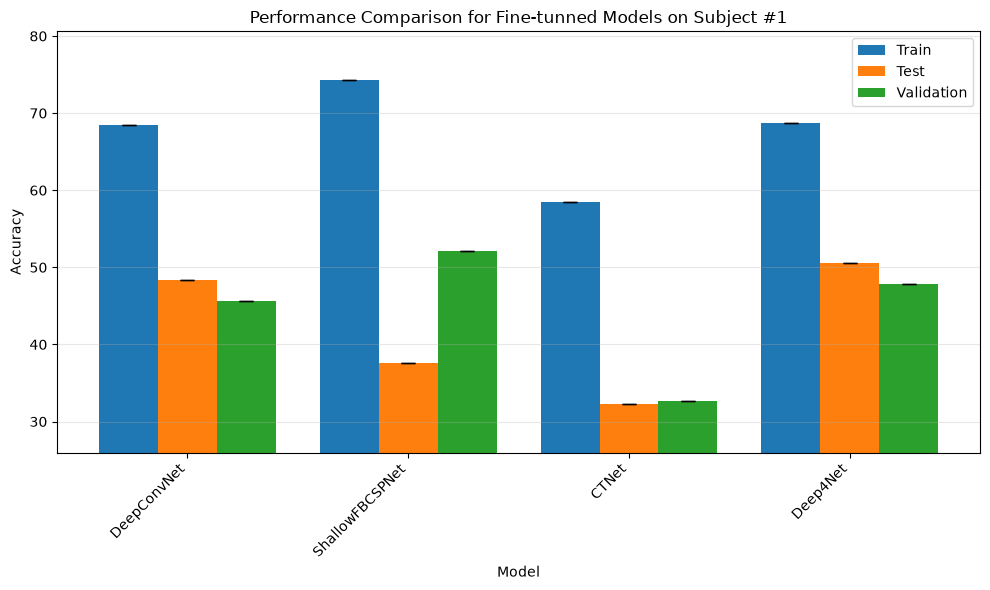


-------- Setting up Fine-tunning for on Subject #2--------
Loading Subject 2 from cache...
Normalizing data based on training set statistics...

Selected Architecture: DeepConvNet
Model loaded successfully from .\Models\Subject 2\Finetuned_14vs1_DeepConvNet_0.005.pth

Model Final Accuracy:
	Train: 77.08978328173374
	Validation: 54.347826086956516

Selected Architecture: ShallowFBCSPNet
Model loaded successfully from .\Models\Subject 2\Finetuned_14vs1_ShallowFBCSPNet_0.005.pth

Model Final Accuracy:
	Train: 76.78018575851394
	Validation: 54.347826086956516

Selected Architecture: CTNet
Model loaded successfully from .\Models\Subject 2\Finetuned_14vs1_CTNet_0.005.pth

Model Final Accuracy:
	Train: 65.01547987616098
	Validation: 45.65217391304348

Selected Architecture: Deep4Net
Model loaded successfully from .\Models\Subject 2\Finetuned_14vs1_Deep4Net_0.005.pth

Model Final Accuracy:
	Train: 69.04024767801857
	Validation: 56.52173913043478


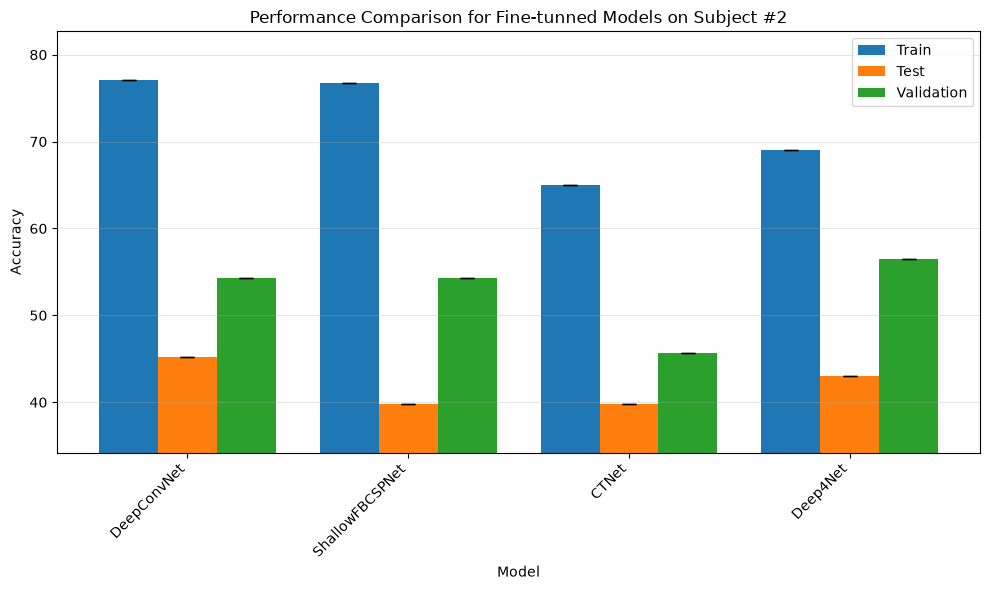


-------- Setting up Fine-tunning for on Subject #3--------
Loading Subject 3 from cache...
Normalizing data based on training set statistics...

Selected Architecture: DeepConvNet
Model loaded successfully from .\Models\Subject 3\Finetuned_14vs1_DeepConvNet_0.005.pth

Model Final Accuracy:
	Train: 95.3560371517028
	Validation: 89.13043478260869

Selected Architecture: ShallowFBCSPNet
Model loaded successfully from .\Models\Subject 3\Finetuned_14vs1_ShallowFBCSPNet_0.005.pth

Model Final Accuracy:
	Train: 98.45201238390094
	Validation: 86.95652173913044

Selected Architecture: CTNet
Model loaded successfully from .\Models\Subject 3\Finetuned_14vs1_CTNet_0.005.pth

Model Final Accuracy:
	Train: 100.0
	Validation: 86.95652173913044

Selected Architecture: Deep4Net
Model loaded successfully from .\Models\Subject 3\Finetuned_14vs1_Deep4Net_0.005.pth

Model Final Accuracy:
	Train: 99.07120743034056
	Validation: 91.30434782608695


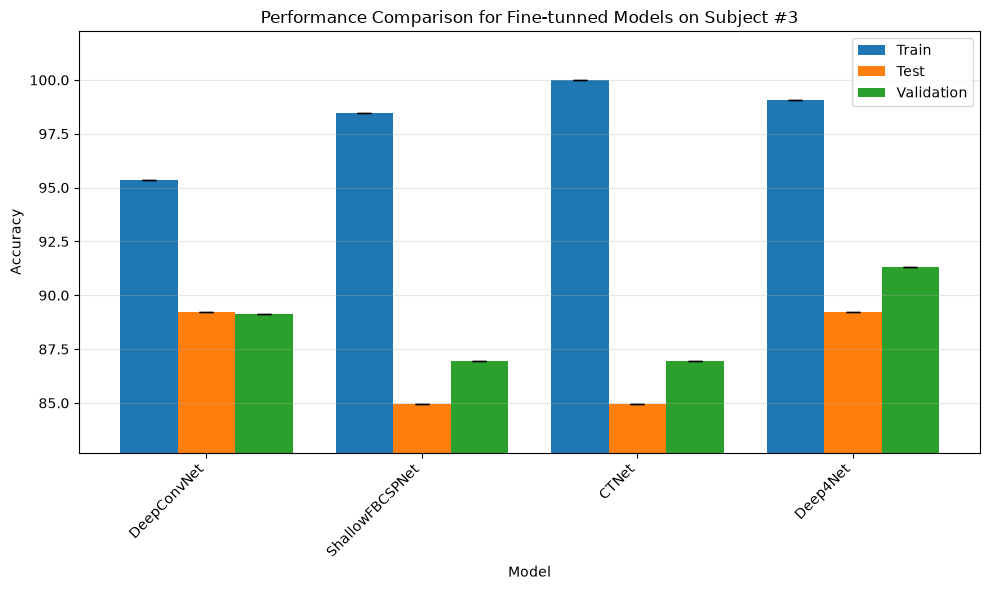


-------- Setting up Fine-tunning for on Subject #4--------
Loading Subject 4 from cache...
Normalizing data based on training set statistics...

Selected Architecture: DeepConvNet
Model loaded successfully from .\Models\Subject 4\Finetuned_14vs1_DeepConvNet_0.005.pth

Model Final Accuracy:
	Train: 98.76160990712074
	Validation: 91.30434782608695

Selected Architecture: ShallowFBCSPNet
Model loaded successfully from .\Models\Subject 4\Finetuned_14vs1_ShallowFBCSPNet_0.005.pth

Model Final Accuracy:
	Train: 94.73684210526315
	Validation: 82.6086956521739

Selected Architecture: CTNet
Model loaded successfully from .\Models\Subject 4\Finetuned_14vs1_CTNet_0.005.pth

Model Final Accuracy:
	Train: 99.69040247678018
	Validation: 91.30434782608695

Selected Architecture: Deep4Net
Model loaded successfully from .\Models\Subject 4\Finetuned_14vs1_Deep4Net_0.005.pth

Model Final Accuracy:
	Train: 99.69040247678018
	Validation: 95.65217391304348


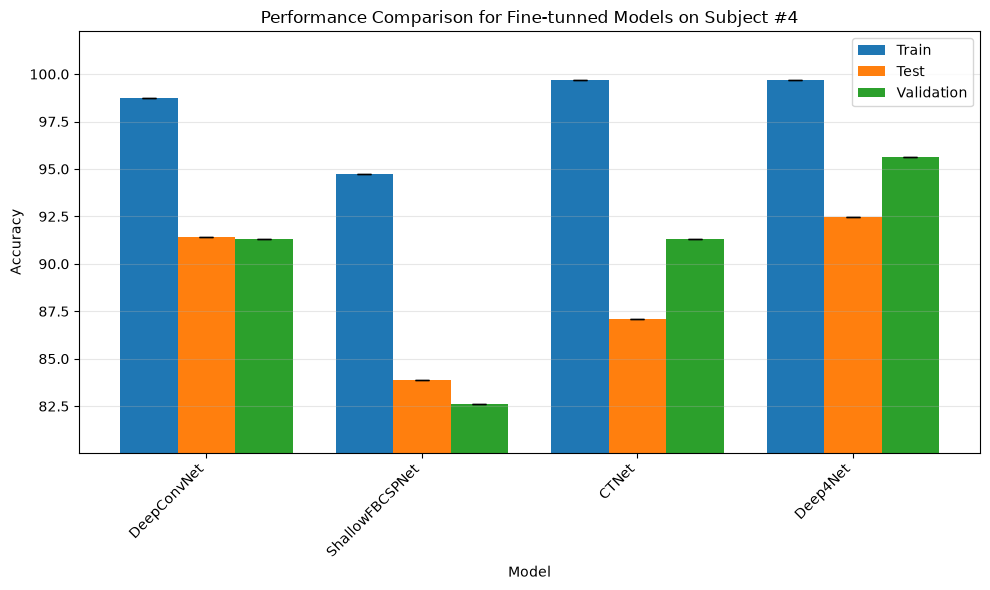


-------- Setting up Fine-tunning for on Subject #5--------
Loading Subject 5 from cache...
Normalizing data based on training set statistics...

Selected Architecture: DeepConvNet
Model loaded successfully from .\Models\Subject 5\Finetuned_14vs1_DeepConvNet_0.005.pth

Model Final Accuracy:
	Train: 69.96904024767801
	Validation: 45.65217391304348

Selected Architecture: ShallowFBCSPNet
Model loaded successfully from .\Models\Subject 5\Finetuned_14vs1_ShallowFBCSPNet_0.005.pth

Model Final Accuracy:
	Train: 75.54179566563467
	Validation: 39.130434782608695

Selected Architecture: CTNet
Model loaded successfully from .\Models\Subject 5\Finetuned_14vs1_CTNet_0.005.pth

Model Final Accuracy:
	Train: 89.47368421052632
	Validation: 36.95652173913043

Selected Architecture: Deep4Net
Model loaded successfully from .\Models\Subject 5\Finetuned_14vs1_Deep4Net_0.005.pth

Model Final Accuracy:
	Train: 68.11145510835914
	Validation: 47.82608695652174


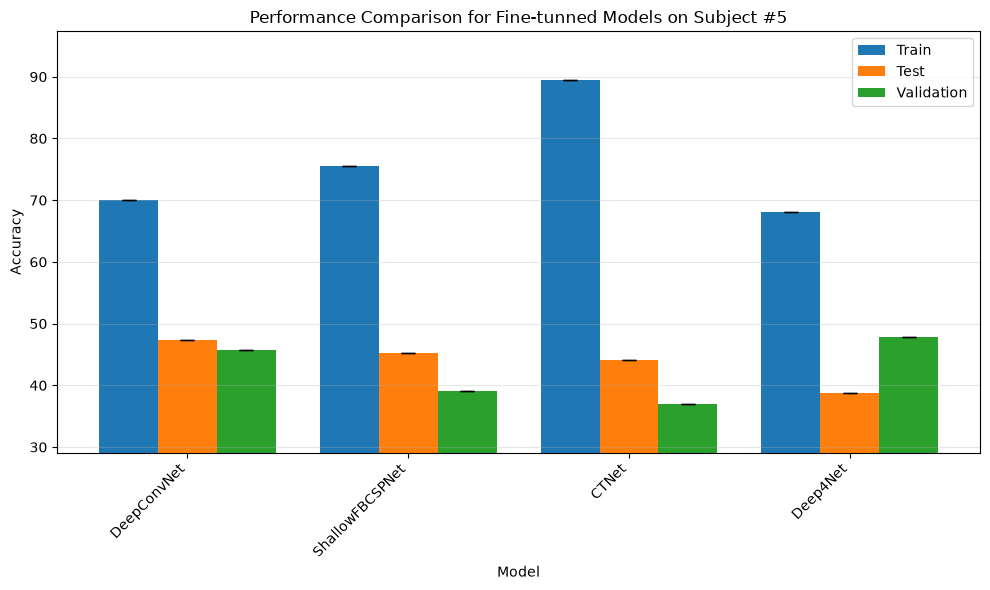


-------- Setting up Fine-tunning for on Subject #6--------
Loading Subject 6 from cache...
Normalizing data based on training set statistics...

Selected Architecture: DeepConvNet
Model loaded successfully from .\Models\Subject 6\Finetuned_14vs1_DeepConvNet_0.005.pth

Model Final Accuracy:
	Train: 82.97213622291022
	Validation: 54.347826086956516

Selected Architecture: ShallowFBCSPNet
Model loaded successfully from .\Models\Subject 6\Finetuned_14vs1_ShallowFBCSPNet_0.005.pth

Model Final Accuracy:
	Train: 83.28173374613003
	Validation: 41.30434782608695

Selected Architecture: CTNet
Model loaded successfully from .\Models\Subject 6\Finetuned_14vs1_CTNet_0.005.pth

Model Final Accuracy:
	Train: 69.04024767801857
	Validation: 54.347826086956516

Selected Architecture: Deep4Net
Model loaded successfully from .\Models\Subject 6\Finetuned_14vs1_Deep4Net_0.005.pth

Model Final Accuracy:
	Train: 91.95046439628483
	Validation: 65.21739130434783


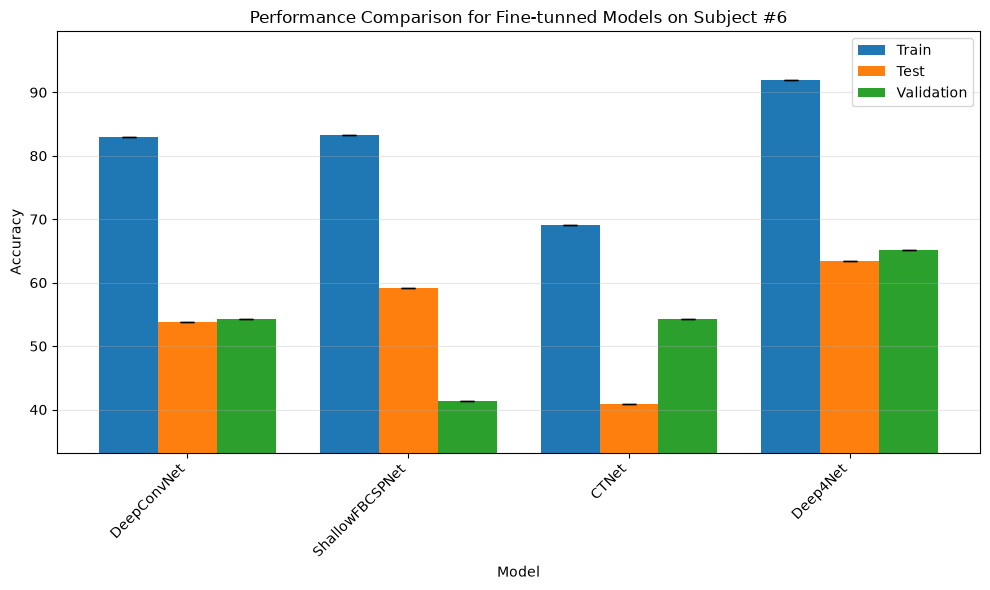


-------- Setting up Fine-tunning for on Subject #7--------
Loading Subject 7 from cache...
Normalizing data based on training set statistics...

Selected Architecture: DeepConvNet
Model loaded successfully from .\Models\Subject 7\Finetuned_14vs1_DeepConvNet_0.005.pth

Model Final Accuracy:
	Train: 89.78328173374614
	Validation: 54.347826086956516

Selected Architecture: ShallowFBCSPNet
Model loaded successfully from .\Models\Subject 7\Finetuned_14vs1_ShallowFBCSPNet_0.005.pth

Model Final Accuracy:
	Train: 85.13931888544892
	Validation: 45.65217391304348

Selected Architecture: CTNet
Model loaded successfully from .\Models\Subject 7\Finetuned_14vs1_CTNet_0.005.pth

Model Final Accuracy:
	Train: 81.73374613003097
	Validation: 41.30434782608695

Selected Architecture: Deep4Net
Model loaded successfully from .\Models\Subject 7\Finetuned_14vs1_Deep4Net_0.005.pth

Model Final Accuracy:
	Train: 92.26006191950464
	Validation: 50.0


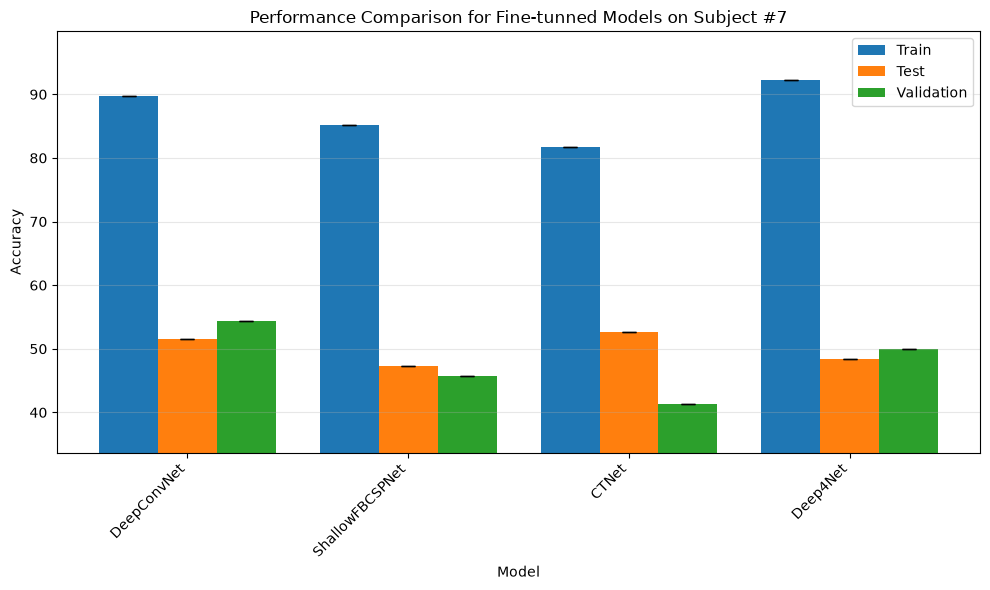


-------- Setting up Fine-tunning for on Subject #8--------
Loading Subject 8 from cache...
Normalizing data based on training set statistics...

Selected Architecture: DeepConvNet
Model loaded successfully from .\Models\Subject 8\Finetuned_14vs1_DeepConvNet_0.005.pth

Model Final Accuracy:
	Train: 83.59133126934985
	Validation: 50.0

Selected Architecture: ShallowFBCSPNet
Model loaded successfully from .\Models\Subject 8\Finetuned_14vs1_ShallowFBCSPNet_0.005.pth

Model Final Accuracy:
	Train: 80.18575851393189
	Validation: 45.65217391304348

Selected Architecture: CTNet
Model loaded successfully from .\Models\Subject 8\Finetuned_14vs1_CTNet_0.005.pth

Model Final Accuracy:
	Train: 60.371517027863774
	Validation: 41.30434782608695

Selected Architecture: Deep4Net
Model loaded successfully from .\Models\Subject 8\Finetuned_14vs1_Deep4Net_0.005.pth

Model Final Accuracy:
	Train: 85.75851393188854
	Validation: 47.82608695652174


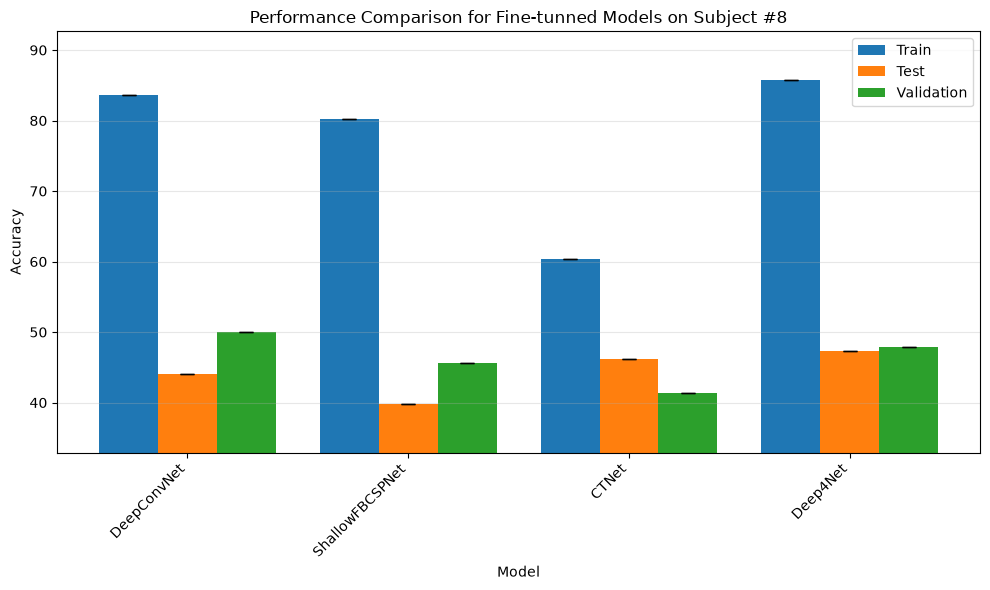


-------- Setting up Fine-tunning for on Subject #9--------
Loading Subject 9 from cache...
Normalizing data based on training set statistics...

Selected Architecture: DeepConvNet
Model loaded successfully from .\Models\Subject 9\Finetuned_14vs1_DeepConvNet_0.005.pth

Model Final Accuracy:
	Train: 84.52012383900929
	Validation: 60.86956521739131

Selected Architecture: ShallowFBCSPNet
Model loaded successfully from .\Models\Subject 9\Finetuned_14vs1_ShallowFBCSPNet_0.005.pth

Model Final Accuracy:
	Train: 78.63777089783281
	Validation: 45.65217391304348

Selected Architecture: CTNet
Model loaded successfully from .\Models\Subject 9\Finetuned_14vs1_CTNet_0.005.pth

Model Final Accuracy:
	Train: 68.73065015479877
	Validation: 47.82608695652174

Selected Architecture: Deep4Net
Model loaded successfully from .\Models\Subject 9\Finetuned_14vs1_Deep4Net_0.005.pth

Model Final Accuracy:
	Train: 87.92569659442725
	Validation: 71.73913043478261


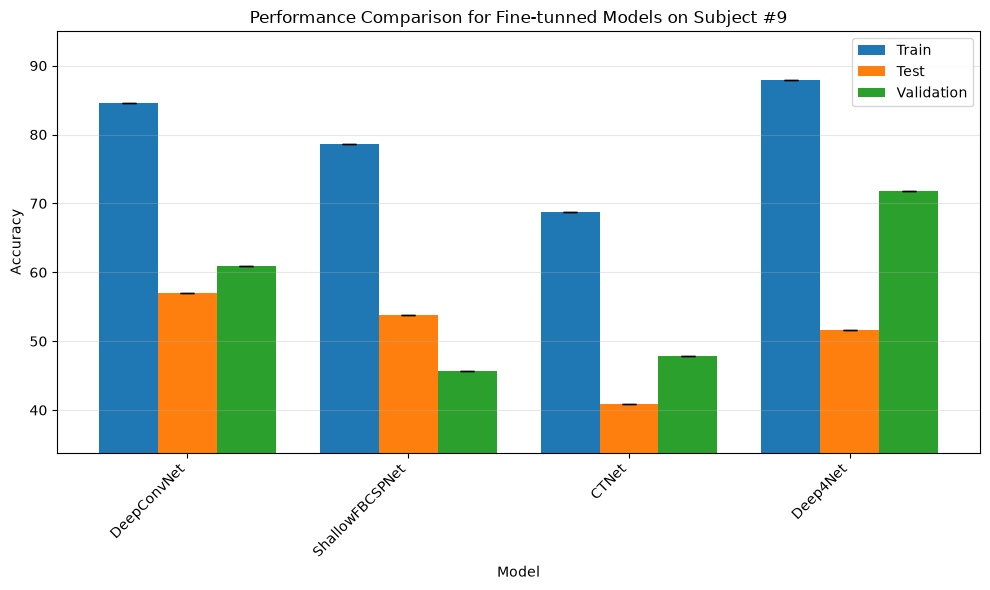


-------- Setting up Fine-tunning for on Subject #10--------
Loading Subject 10 from cache...
Normalizing data based on training set statistics...

Selected Architecture: DeepConvNet
Model loaded successfully from .\Models\Subject 10\Finetuned_14vs1_DeepConvNet_0.005.pth

Model Final Accuracy:
	Train: 83.59133126934985
	Validation: 60.86956521739131

Selected Architecture: ShallowFBCSPNet
Model loaded successfully from .\Models\Subject 10\Finetuned_14vs1_ShallowFBCSPNet_0.005.pth

Model Final Accuracy:
	Train: 96.59442724458205
	Validation: 58.69565217391305

Selected Architecture: CTNet
Model loaded successfully from .\Models\Subject 10\Finetuned_14vs1_CTNet_0.005.pth

Model Final Accuracy:
	Train: 89.47368421052632
	Validation: 45.65217391304348

Selected Architecture: Deep4Net
Model loaded successfully from .\Models\Subject 10\Finetuned_14vs1_Deep4Net_0.005.pth

Model Final Accuracy:
	Train: 68.11145510835914
	Validation: 58.69565217391305


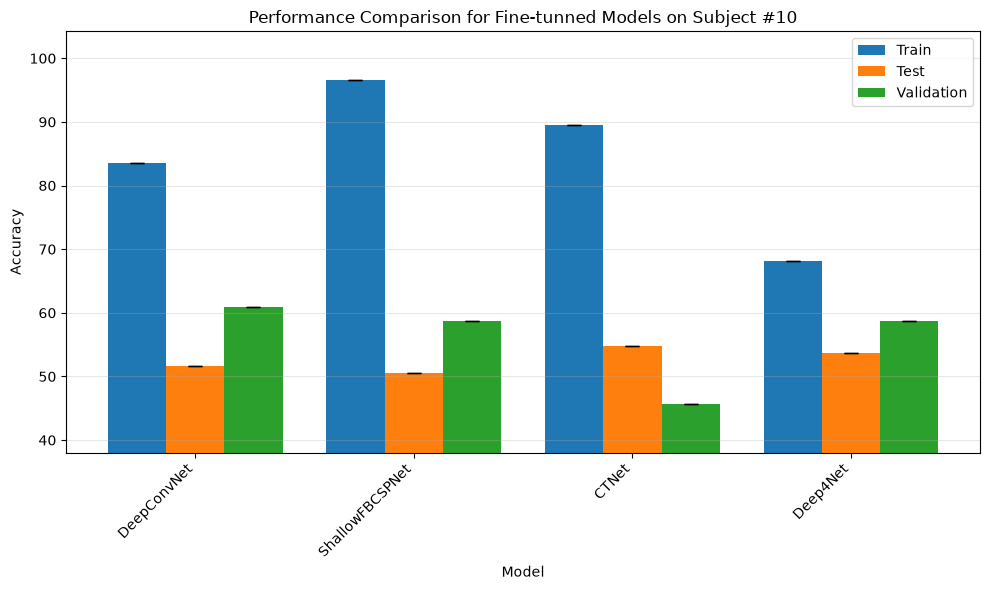


-------- Setting up Fine-tunning for on Subject #11--------
Loading Subject 11 from cache...
Normalizing data based on training set statistics...

Selected Architecture: DeepConvNet
Model loaded successfully from .\Models\Subject 11\Finetuned_14vs1_DeepConvNet_0.005.pth

Model Final Accuracy:
	Train: 90.71207430340557
	Validation: 63.04347826086957

Selected Architecture: ShallowFBCSPNet
Model loaded successfully from .\Models\Subject 11\Finetuned_14vs1_ShallowFBCSPNet_0.005.pth

Model Final Accuracy:
	Train: 89.1640866873065
	Validation: 60.86956521739131

Selected Architecture: CTNet
Model loaded successfully from .\Models\Subject 11\Finetuned_14vs1_CTNet_0.005.pth

Model Final Accuracy:
	Train: 78.94736842105263
	Validation: 45.65217391304348

Selected Architecture: Deep4Net
Model loaded successfully from .\Models\Subject 11\Finetuned_14vs1_Deep4Net_0.005.pth

Model Final Accuracy:
	Train: 86.687306501548
	Validation: 54.347826086956516


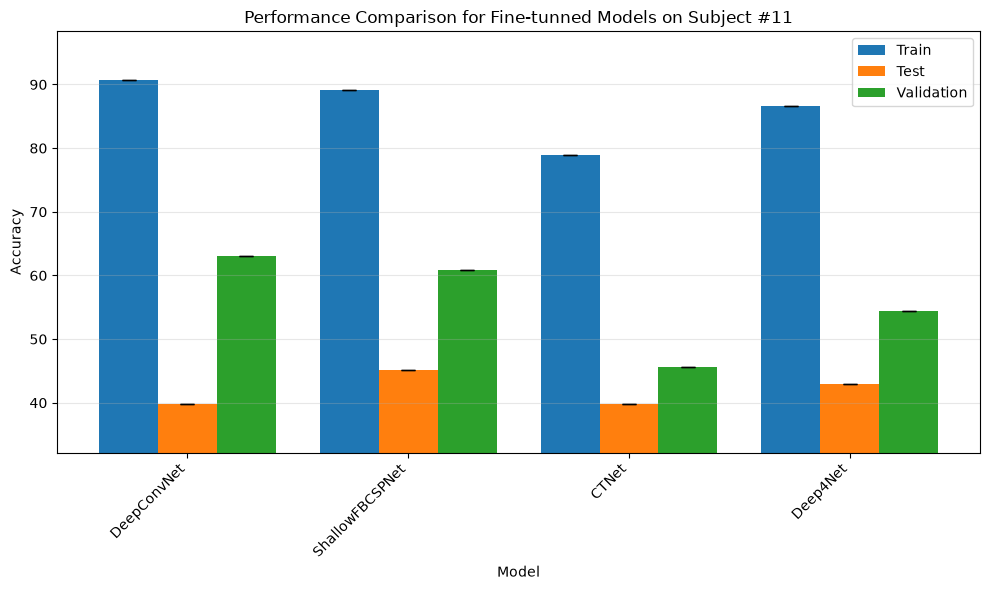


-------- Setting up Fine-tunning for on Subject #12--------
Loading Subject 12 from cache...
Normalizing data based on training set statistics...

Selected Architecture: DeepConvNet
Model loaded successfully from .\Models\Subject 12\Finetuned_14vs1_DeepConvNet_0.005.pth

Model Final Accuracy:
	Train: 65.01547987616098
	Validation: 56.52173913043478

Selected Architecture: ShallowFBCSPNet
Model loaded successfully from .\Models\Subject 12\Finetuned_14vs1_ShallowFBCSPNet_0.005.pth

Model Final Accuracy:
	Train: 75.85139318885449
	Validation: 45.65217391304348

Selected Architecture: CTNet
Model loaded successfully from .\Models\Subject 12\Finetuned_14vs1_CTNet_0.005.pth

Model Final Accuracy:
	Train: 57.89473684210527
	Validation: 28.26086956521739

Selected Architecture: Deep4Net
Model loaded successfully from .\Models\Subject 12\Finetuned_14vs1_Deep4Net_0.005.pth

Model Final Accuracy:
	Train: 95.97523219814241
	Validation: 60.86956521739131


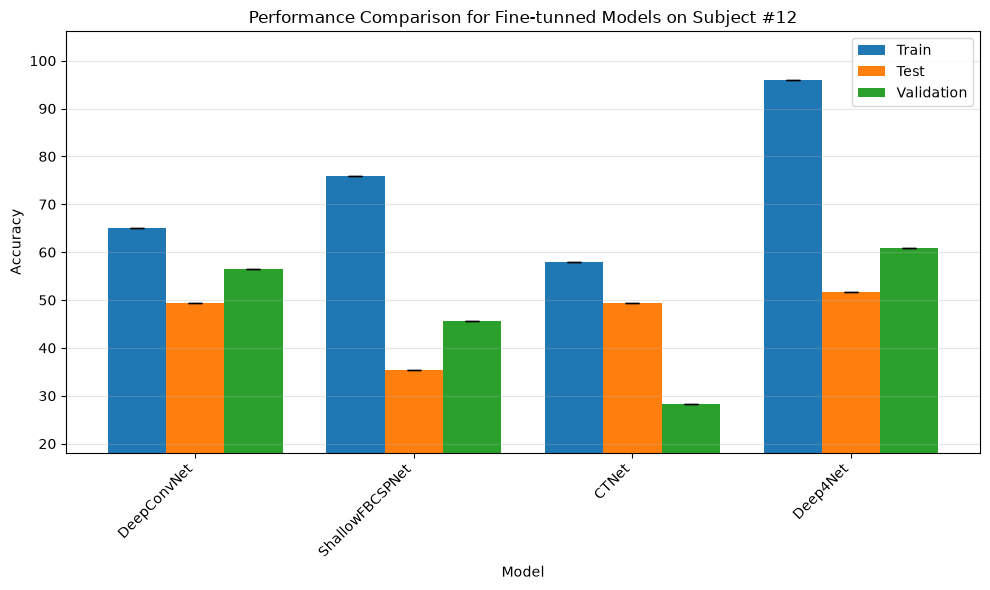


-------- Setting up Fine-tunning for on Subject #13--------
Loading Subject 13 from cache...
Normalizing data based on training set statistics...

Selected Architecture: DeepConvNet
Model loaded successfully from .\Models\Subject 13\Finetuned_14vs1_DeepConvNet_0.005.pth

Model Final Accuracy:
	Train: 79.56656346749226
	Validation: 54.347826086956516

Selected Architecture: ShallowFBCSPNet
Model loaded successfully from .\Models\Subject 13\Finetuned_14vs1_ShallowFBCSPNet_0.005.pth

Model Final Accuracy:
	Train: 95.6656346749226
	Validation: 58.69565217391305

Selected Architecture: CTNet
Model loaded successfully from .\Models\Subject 13\Finetuned_14vs1_CTNet_0.005.pth

Model Final Accuracy:
	Train: 93.80804953560371
	Validation: 41.30434782608695

Selected Architecture: Deep4Net
Model loaded successfully from .\Models\Subject 13\Finetuned_14vs1_Deep4Net_0.005.pth

Model Final Accuracy:
	Train: 66.56346749226006
	Validation: 60.86956521739131


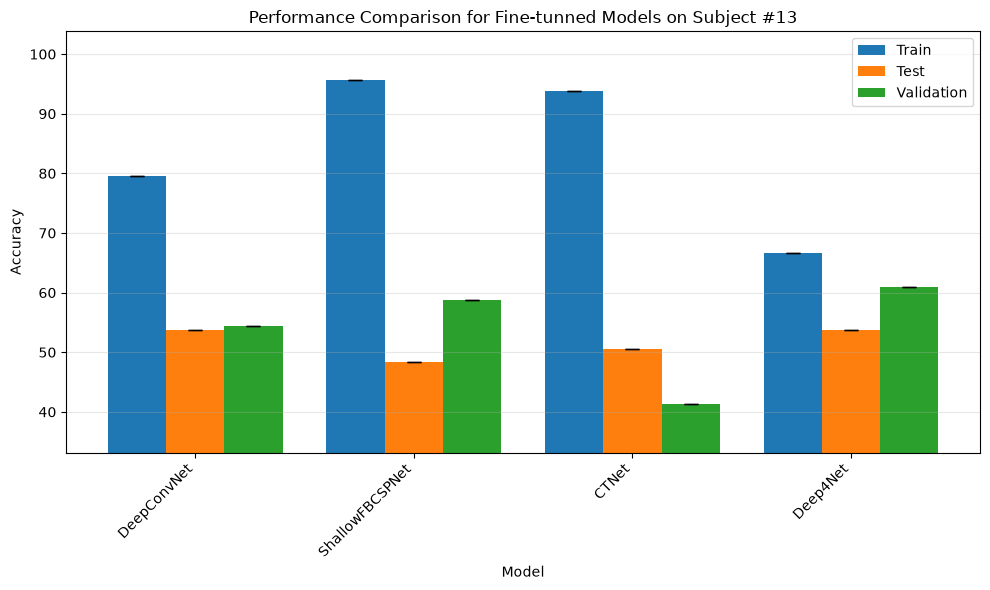


-------- Setting up Fine-tunning for on Subject #14--------
Loading Subject 14 from cache...
Normalizing data based on training set statistics...

Selected Architecture: DeepConvNet
Model loaded successfully from .\Models\Subject 14\Finetuned_14vs1_DeepConvNet_0.005.pth

Model Final Accuracy:
	Train: 90.40247678018576
	Validation: 65.21739130434783

Selected Architecture: ShallowFBCSPNet
Model loaded successfully from .\Models\Subject 14\Finetuned_14vs1_ShallowFBCSPNet_0.005.pth

Model Final Accuracy:
	Train: 69.04024767801857
	Validation: 30.434782608695656

Selected Architecture: CTNet
Model loaded successfully from .\Models\Subject 14\Finetuned_14vs1_CTNet_0.005.pth

Model Final Accuracy:
	Train: 63.77708978328174
	Validation: 41.30434782608695

Selected Architecture: Deep4Net
Model loaded successfully from .\Models\Subject 14\Finetuned_14vs1_Deep4Net_0.005.pth

Model Final Accuracy:
	Train: 87.61609907120743
	Validation: 52.17391304347826


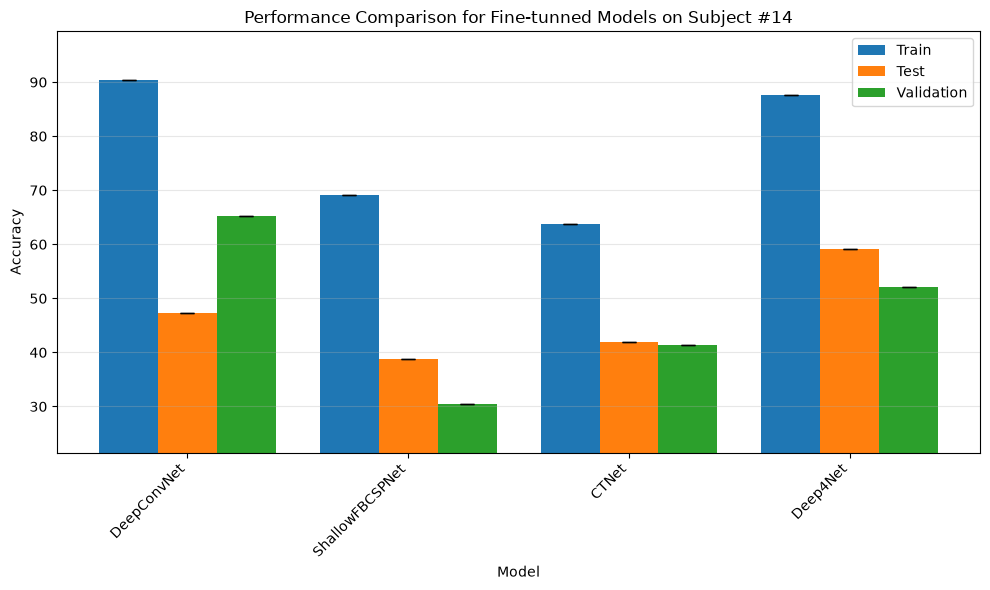


-------- Setting up Fine-tunning for on Subject #15--------
Loading Subject 15 from cache...
Normalizing data based on training set statistics...

Selected Architecture: DeepConvNet
Model loaded successfully from .\Models\Subject 15\Finetuned_14vs1_DeepConvNet_0.005.pth

Model Final Accuracy:
	Train: 64.39628482972137
	Validation: 52.17391304347826

Selected Architecture: ShallowFBCSPNet
Model loaded successfully from .\Models\Subject 15\Finetuned_14vs1_ShallowFBCSPNet_0.005.pth

Model Final Accuracy:
	Train: 89.47368421052632
	Validation: 54.347826086956516

Selected Architecture: CTNet
Model loaded successfully from .\Models\Subject 15\Finetuned_14vs1_CTNet_0.005.pth

Model Final Accuracy:
	Train: 83.90092879256966
	Validation: 36.95652173913043

Selected Architecture: Deep4Net
Model loaded successfully from .\Models\Subject 15\Finetuned_14vs1_Deep4Net_0.005.pth

Model Final Accuracy:
	Train: 62.848297213622295
	Validation: 56.52173913043478


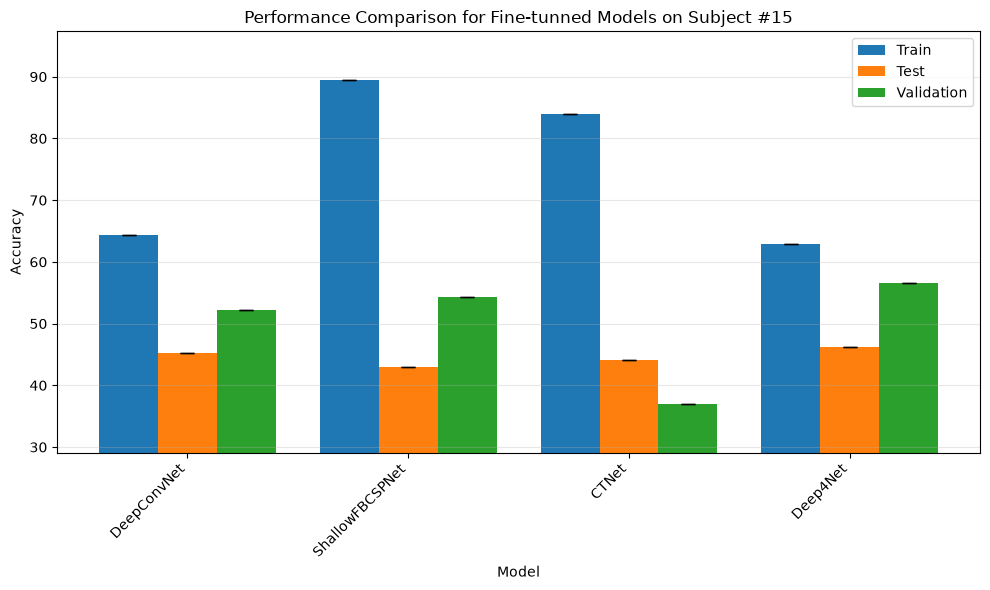

Data saved successfully to .\Results\Results.xlsx (Sheet: Fine-tune 14vs1)


In [12]:
for subject_removed in range(1, SUBJECT_COUNT + 1):
    print(f"\n-------- Setting up Fine-tunning for on Subject #{subject_removed}--------")
    
    train_loader, val_loader, test_loader = data_loader_factory.get_dataloaders(subject=subject_removed, random_seed=RANDOM_SEED)
    train_acc, test_acc, val_acc = [], [], []
    
    for architecture in MODEL_ARCHITECTURES:
        print('\nSelected Architecture:', architecture)
        pretrained_model_path = str(MODEL_PATH + f'Pretrained\\{architecture}_{P_LEARNING_RATE}_RemovedSubject#{subject_removed}.pth')
        model_path = str(MODEL_PATH + f'Subject {subject_removed}\\Finetuned_14vs1_{architecture}_{LEARNING_RATE}.pth')
        model = EEGModel(
            criterion=CRITERION,
            learning_rate=P_LEARNING_RATE,
            architecture_key=architecture,
            random_seed=RANDOM_SEED,
            device=DEVICE
        )
        """model.load_model(pretrained_model_path)
        model.fit(
            train_loader=train_loader,
            val_loader=val_loader,
            max_epochs=MAX_EPOCH,
            patience=PATIENCE,
            save_path=model_path,
            verbose=False
        )"""
        model.load_model(model_path)

        train_acc.append(model.evaluate_accuracy(train_loader))
        test_acc.append(model.evaluate_accuracy(test_loader))
        val_acc.append(model.evaluate_accuracy(val_loader))
        print('\nModel Final Accuracy:')
        print('\tTrain:', train_acc[-1])
        print('\tValidation:', val_acc[-1])

        data_saver.set_data(architecture, 'Train', 'avg', subject_removed, train_acc[-1])
        data_saver.set_data(architecture, 'Test', 'avg', subject_removed, test_acc[-1])
        data_saver.set_data(architecture, 'Validation', 'avg', subject_removed, val_acc[-1])

    visualizer.plot_model_performance(
        MODEL_ARCHITECTURES,
        means=[train_acc, test_acc, val_acc],
        vars=[np.zeros(len(train_acc)), np.zeros(len(test_acc)), np.zeros(len(val_acc))],
        legend=['Train', 'Test', 'Validation'],
        plot_name=f"Performance Comparison for Fine-tunned Models on Subject #{subject_removed}"
    )
data_saver.save_excel("Results.xlsx", 'Fine-tune 14vs1')


## Ensemble

### Average Voting

In [11]:
train_accs, test_accs, val_accs = [], [], []
for subject_id in range(1, 1 + SUBJECT_COUNT):
    train_loader, val_loader, test_loader = data_loader_factory.get_dataloaders(subject=subject_id, random_seed=RANDOM_SEED)
    model_list = []
    for architecture in MODEL_ARCHITECTURES:
        model_path = str(MODEL_PATH + f'Subject {subject_id}\\Finetuned_14vs1_{architecture}_{LEARNING_RATE}.pth')
        model = EEGModel(
            criterion=CRITERION,
            learning_rate=LEARNING_RATE,
            architecture_key=architecture,
            random_seed=RANDOM_SEED,
            device=DEVICE
        )
        model.load_model(model_path)
        model_list.append(model)

    ae = AverageEnsemble(model_list)
    train_acc = ae.evaluate_accuracy(train_loader, DEVICE)
    test_acc = ae.evaluate_accuracy(test_loader, DEVICE)
    val_acc = ae.evaluate_accuracy(val_loader, DEVICE)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    val_accs.append(val_acc)
    data_saver.set_data('Avg Ensmble', 'Train', 'avg', subject_id, train_acc)
    data_saver.set_data('Avg Ensmble', 'Test', 'avg', subject_id, test_acc)
    data_saver.set_data('Avg Ensmble', 'Validation', 'avg', subject_id, val_acc)
    print(f'Subject #{subject_id}:\tTest Acc: {test_acc:.4f}\tValidation Acc: {val_acc:.4f}')

data_saver.save_excel("Results.xlsx", 'Average Ensemble 14 vs 1')

Loading Subject 1 from cache...
Normalizing data based on training set statistics...
Model loaded successfully from .\Models\Subject 1\Finetuned_14vs1_DeepConvNet_0.005.pth
Model loaded successfully from .\Models\Subject 1\Finetuned_14vs1_ShallowFBCSPNet_0.005.pth
Model loaded successfully from .\Models\Subject 1\Finetuned_14vs1_CTNet_0.005.pth
Model loaded successfully from .\Models\Subject 1\Finetuned_14vs1_Deep4Net_0.005.pth
Subject #1:	Test Acc: 0.4946	Validation Acc: 0.4348
Loading Subject 2 from cache...
Normalizing data based on training set statistics...
Model loaded successfully from .\Models\Subject 2\Finetuned_14vs1_DeepConvNet_0.005.pth
Model loaded successfully from .\Models\Subject 2\Finetuned_14vs1_ShallowFBCSPNet_0.005.pth
Model loaded successfully from .\Models\Subject 2\Finetuned_14vs1_CTNet_0.005.pth
Model loaded successfully from .\Models\Subject 2\Finetuned_14vs1_Deep4Net_0.005.pth
Subject #2:	Test Acc: 0.4731	Validation Acc: 0.5870
Loading Subject 3 from cache...
